In [35]:
!gdown 1mc89F1dkQ6XRQnwQTqqryjaXt5ZWXTT0
!unzip BTC-Daily.zip

Downloading...
From: https://drive.google.com/uc?id=1mc89F1dkQ6XRQnwQTqqryjaXt5ZWXTT0
To: /Users/juberry/Documents/Code/Machine-Learning/Machine Learning/Supervised_Learning/Regression/Linear Regression/BTC-Daily.zip
100%|██████████████████████████████████████| 95.7k/95.7k [00:00<00:00, 527kB/s]
Archive:  BTC-Daily.zip
  inflating: BTC-Daily.csv           


In [36]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

df = pd.read_csv("/Users/juberry/Documents/Code/Machine-Learning/Data/Linear Regression/BTC-Daily.csv")
df = df.drop_duplicates()
df = df.dropna()
df.head()

,unix,date,symbol,open,high,low,close,Volume BTC,Volume USD
0,1646092800,2022-03-01 00:00:00,BTC/USD,43221.71,43626.49,43185.48,43185.48,49.006289,2.116360e+06
1,1646006400,2022-02-28 00:00:00,BTC/USD,37717.10,44256.08,37468.99,43178.98,3160.618070,1.364723e+08
2,1645920000,2022-02-27 00:00:00,BTC/USD,39146.66,39886.92,37015.74,37712.68,1701.817043,6.418008e+07
3,1645833600,2022-02-26 00:00:00,BTC/USD,39242.64,40330.99,38600.00,39146.66,912.724087,3.573010e+07
4,1645747200,2022-02-25 00:00:00,BTC/USD,38360.93,39727.97,38027.61,39231.64,2202.851827,8.642149e+07


#X: open, high, low, volumn btc, volumn usd
#y: close

In [41]:
df.isnull().sum()

unix          0
date          0
symbol        0
open          0
high          0
low           0
close         0
Volume BTC    0
Volume USD    0
dtype: int64

In [37]:
X = df[["open", "high", "low"]].values
y = df["close"].values

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(2651, 3)
(2651,)
(2120, 3) (531, 3)
(2120,) (531,)


In [38]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train[:5])

[[-0.56898172 -0.56538206 -0.57210683]
 [-0.70201238 -0.70307918 -0.70180671]
 [-0.32681426 -0.3350589  -0.31416191]
 [-0.69498298 -0.69639529 -0.69480331]
 [-0.45934561 -0.45903433 -0.45553328]]


In [39]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
print("test:",y_test[:5])
print("pred:",y_pred[:5])
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Square Error (MSE):", round(mse, 4))
print("Mean Absolute Error (MAE):", round(mae, 4))
print("R-squared:", round(r2, 4))

test: [  236.46 46392.81  6383.46   451.    5559.26]
pred: [  239.56364108 46723.90745524  6354.58902349   451.9860566
  5614.69596628]
Mean Square Error (MSE): 98272.8494
Mean Absolute Error (MAE): 131.7611
R-squared: 0.9996


Text(0.5, 0, 'Date')

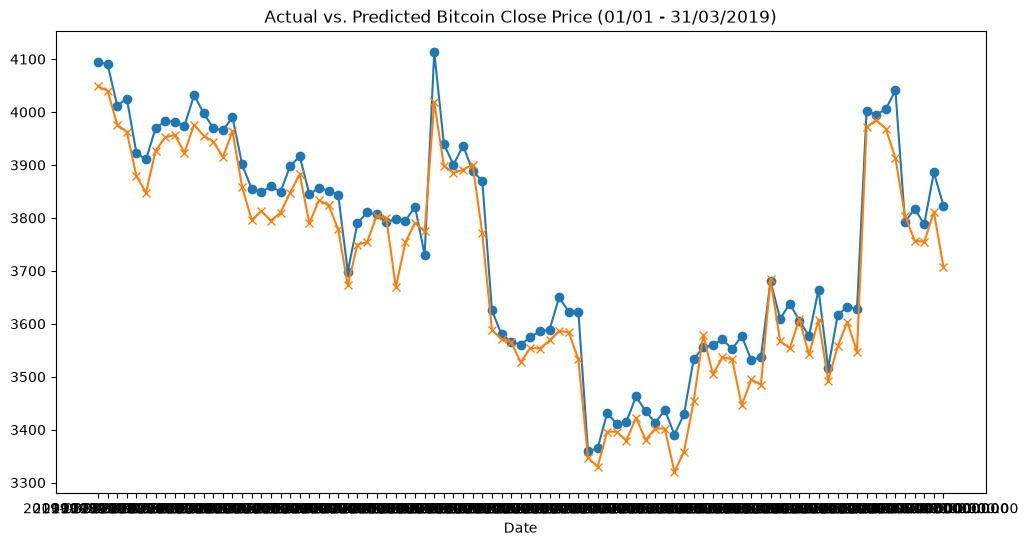

In [40]:
# Lọc dữ liệu 2019 Q1
df_2019_Q1 = df[(df["date"] >= "2019-01-01") & (df["date"] <= "2019-03-31")].copy()

# Chọn đúng các cột feature đã train
X_2019 = df_2019_Q1[["open", "low", "high"]].values
X_2019_scaled = scaler.transform(X_2019)
y_2019 = df_2019_Q1["close"].values

# Dự đoán bằng model sklearn
y_pred_2019 = lr.predict(X_2019_scaled)

# Gắn vào dataframe để tiện vẽ
df_2019_Q1["predicted_close"] = y_pred_2019
# Vẽ
plt.figure(figsize=(12,6))
plt.plot(df_2019_Q1["date"], df_2019_Q1["close"], label="Actual Close Price", marker="o")
plt.plot(df_2019_Q1["date"], df_2019_Q1["predicted_close"], label="Predicted Close Price (Model)", marker="x")
plt.title("Actual vs. Predicted Bitcoin Close Price (01/01 - 31/03/2019)")
plt.xlabel("Date")